# Walking nudge results

This notebook checks the consistency of the results from the walking nudge method.

__Results__

21 of the 100 sets converge on one set of values that have better fitness than the other sets manage. Go with these as the "best" values.

## Code setup

In [1]:
import polars as pl
import os
import numpy as np
import itertools
import matplotlib.pyplot as plt
import matplotlib.ticker  # for axis tick location

# Print general numbers, not scientific notation:
np.set_printoptions(suppress=True)

## Load data

### Admissions

In [2]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [3]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the health and age proportions:

In [4]:
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}'
               for q in qmin_list for a in age_numbers]
# Check the first few:
print(coeff_names[:3])

# Quantile names:
quantile_str_list = sorted(list(set([c.split('_')[-1] for c in coeff_names])))

['age_less65_q00', 'age_65_q00', 'age_70_q00']


Gather admissions data by deprivation quantile:

In [5]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

### Age-admissions coefficients

Starting SSNAP coefficients:

In [6]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [7]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [8]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

Turn them into a dictionary:

In [9]:
labels = ['less65', '65', '70', '75', 'over80']
coeffs_ssnap_dict = (
    dict(zip(labels, df_pop_admissions['prob_stroke_given_age'].to_numpy())))

coeffs_ssnap_dict

{'less65': 0.000408,
 '65': 0.002644,
 '70': 0.003735,
 '75': 0.006005,
 'over80': 0.011558}

Pick out admissions numbers:

In [10]:
admissions_by_age = (
    df_pop_admissions['admissions_annual_boost'].to_numpy().flatten())

### Best results from genetic algorithm

Data stored as scale factors for the SSNAP-derived coefficients.

In [11]:
df_best_gens = pl.read_csv(os.path.join('outputs', 'best_inds_deap.csv'))

In [12]:
df_best_gens.head()

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed00""",33.0,1.3,1.2,1.332,1.237,1.2,1.026,1.145,1.151,1.041,1.1,1.0,1.0,0.988,0.938,1.0,0.862,0.9,0.945,0.938,0.937,0.8,0.9,0.732,0.832,0.874,238.372,0.584365,0.502719,0.579147,0.616005,0.598245,0.606993
"""randomseed01""",33.0,1.1,1.3,1.305,1.3,1.231,1.1,1.1,1.1,1.023,1.1,1.0,1.0,1.0,1.0,1.0,0.969,0.9,0.9,0.892,0.9,0.837,0.849,0.8,0.8,0.894,238.507,0.575882,0.471584,0.579147,0.616005,0.583824,0.606993
"""randomseed02""",43.0,1.273,1.308,1.175,1.2,1.214,0.981,1.1,1.103,1.1,1.131,0.949,0.987,1.046,1.0,1.0,0.949,0.979,0.896,0.9,0.9,0.844,0.773,0.861,0.8,0.88,238.037,0.58383,0.485431,0.583466,0.616005,0.606683,0.606993
"""randomseed03""",28.0,1.171,1.3,1.327,1.186,1.3,1.1,1.198,1.1,1.1,1.1,1.042,1.0,1.0,1.0,0.971,0.881,0.9,0.894,1.0,0.9,0.8,0.771,0.808,0.7,0.9,239.49,0.585993,0.508469,0.583466,0.631482,0.605116,0.580367
"""randomseed04""",39.0,1.2,1.2,1.25,1.225,1.293,1.1,1.1,1.11,1.069,1.1,0.976,1.019,1.0,1.0,0.961,0.925,0.904,0.9,0.915,0.91,0.8,0.9,0.844,0.8,0.879,238.453,0.591769,0.508469,0.579147,0.631482,0.612783,0.606993


Convert the scale factors to the actual age-deprivation coefficient values using the SSNAP coefficients.

In [13]:
for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = df_best_gens[coeff] * coeffs_ssnap_dict[key]
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

Round results:

In [14]:
# Set up dictionary with how many decimal places to round to:
labels = ['less65', '65', '70', '75', 'over80']
round_dict = dict(zip(labels, [4, 3, 3, 3, 3]))

for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = np.round(df_best_gens[coeff], round_dict[key])
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

Drop the measures of goodness of fit now that the coefficients have been rounded:

In [15]:
df_best_gens = df_best_gens.drop(
    ['fitness'] + [c for c in df_best_gens.columns if c.startswith('r2')])

### Nudged results

In [16]:
df_best_nudged = pl.read_csv(os.path.join('outputs', 'nudge_walk_best.csv'))

In [17]:
df_nudge_history = pl.read_csv(os.path.join('outputs', 'nudge_walk_history.csv'))

In [18]:
dict_nudged_results = {}

for d in df_nudge_history['dir'].unique():
    df = df_nudge_history.filter(df_nudge_history['dir'] == d)
    dict_nudged_results[d] = df

In [19]:
dict_nudged_results['randomseed42']

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08,dir
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.0005,0.003,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,240.149871,1.082642,259.996431,0.980725,0.955842,1.013293,0.99959,0.994494,113.136822,107.849722,108.96863,104.473782,102.232696,"""randomseed42"""
0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.191107,1.055834,252.546109,0.980725,1.01735,1.013293,0.99959,0.994494,111.087199,107.849722,108.96863,104.473782,102.232696,"""randomseed42"""
0.0005,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.324924,1.045778,249.234929,0.980725,1.007294,1.013293,0.99959,0.994494,111.087199,108.616129,106.276266,104.473782,102.232696,"""randomseed42"""
0.0005,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,237.766384,1.040741,247.45327,0.980725,1.007294,1.013293,0.99959,0.999531,111.087199,107.931813,106.276266,103.908818,102.232696,"""randomseed42"""
0.0006,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,238.449844,1.033248,246.377826,0.988218,1.007294,1.013293,0.99959,0.999531,112.578832,107.931813,106.276266,103.869578,102.232696,"""randomseed42"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0006,0.004,0.005,0.007,0.012,0.0004,0.004,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,237.714126,1.033395,245.652493,0.988218,1.007294,0.990317,0.99959,0.995774,111.713695,107.931813,106.276266,103.869578,101.46549,"""randomseed42"""
0.0006,0.005,0.005,0.007,0.012,0.0004,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.75525,1.026136,244.99543,0.988218,1.000036,0.990317,0.99959,0.995774,112.83844,109.054005,106.276266,103.869578,101.46549,"""randomseed42"""
0.0006,0.005,0.005,0.007,0.012,0.0005,0.003,0.004,0.007,0.012,0.0003,0.002,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0003,0.002,0.002,0.005,0.011,238.79332,1.022947,244.272812,0.991408,1.000036,0.990317,0.99959,0.995774,112.83844,109.368827,106.038015,103.869578,101.46549,"""randomseed42"""


## Nudge history

How many nudges were there? How much did the fitness improve compared with the starting values? Gather the data needed to check this:

In [20]:
dict_check_history = {
    'dir': [],
    'n_loops': [],
    'fitness_before': [],
    'fitness_after': [],
    'n_nudges': [],
}
for d, df in dict_nudged_results.items():
    dict_check_history['dir'].append(d)
    dict_check_history['n_loops'].append(len(df))
    dict_check_history['fitness_before'].append(np.round(df['fitness'][0], 6))
    dict_check_history['fitness_after'].append(np.round(df['fitness'].min(), 6))
    # Calculate how many coefficients have changed from the start value:
    coeffs_start = df[0][coeff_names]
    coeffs_end = df.filter(df['fitness'] == df['fitness'].min())[0][coeff_names]
    n_changed = np.sum(np.sign(coeffs_start - coeffs_end) > 0)
    dict_check_history['n_nudges'].append(n_changed)
    
    
df_check_history = pl.DataFrame()
for k, v in dict_check_history.items():
    df_check_history = df_check_history.with_columns(pl.Series(k, v))

In [21]:
df_check_history.head()

dir,n_loops,fitness_before,fitness_after,n_nudges
str,i64,f64,f64,i64
"""randomseed49""",15,260.632866,244.272812,9
"""randomseed53""",7,270.252214,244.849126,3
"""randomseed30""",8,267.810327,244.272812,6
"""randomseed43""",7,261.720955,244.849126,4
"""randomseed07""",9,274.98787,244.849126,4


How many sets of starting options had X coefficients nudged? n.b. this is just the number of coeffs that changed, not counting how many times they changed.

In [22]:
df_check_history['n_nudges'].value_counts().sort('n_nudges')

n_nudges,count
i64,u32
2,4
3,12
4,32
5,23
6,22
7,3
8,3
9,1


Most sets changed four, five, or six coefficient values.

How many sets of starting options had X rounds of nudging?

In [23]:
df_n_nudge = df_check_history['n_loops'].value_counts().sort('n_loops')
# Subtract one because these dataframes store a copy of the starting values.
df_n_nudge = df_n_nudge.with_columns(pl.Series('n_options', (df_n_nudge['n_loops'] - 1) * 900))

with pl.Config(set_tbl_rows=len(df_n_nudge)):
    display(df_n_nudge)

n_loops,count,n_options
i64,u32,i64
5,1,3600
6,11,4500
7,27,5400
8,22,6300
9,7,7200
10,9,8100
11,4,9000
12,5,9900
13,6,10800


Most of the coefficients had 7 or 8 rounds of nudging for 5400 to 6300 options checked before the final values were decided. Some of the options will be repeated across loops and some of the options will be invalid (coeffs do not increase with age or deprivation).

Quick plot to gauge change in fitness.

The top of each bar is the fitness before the nudging and the bottom of the bar is the fitness after nudging. The bars are ordered with the lowest fitness after on the left, and where there is a tie then the lowest "fitness before" is further left.

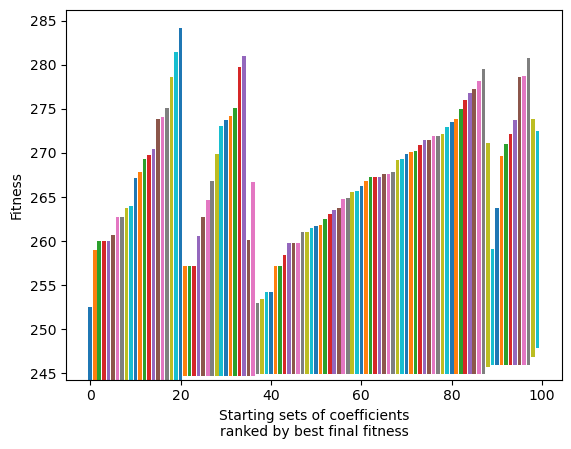

In [24]:
fig, ax = plt.subplots()

# Plot the change in fitness for each set of coeffs in turn:
for d, dir_name in enumerate(df_check_history.sort('fitness_after', 'fitness_before')['dir']):
    df = df_check_history.filter(df_check_history['dir'] == dir_name)
    ax.bar(d, height=(df['fitness_before']-df['fitness_after']), bottom=df['fitness_after'])

# ax.set_ylim(244, 285)

ax.set_ylabel('Fitness')
ax.set_xlabel('Starting sets of coefficients\nranked by best final fitness')
plt.show()

Plot change in fitness with number of iterations:

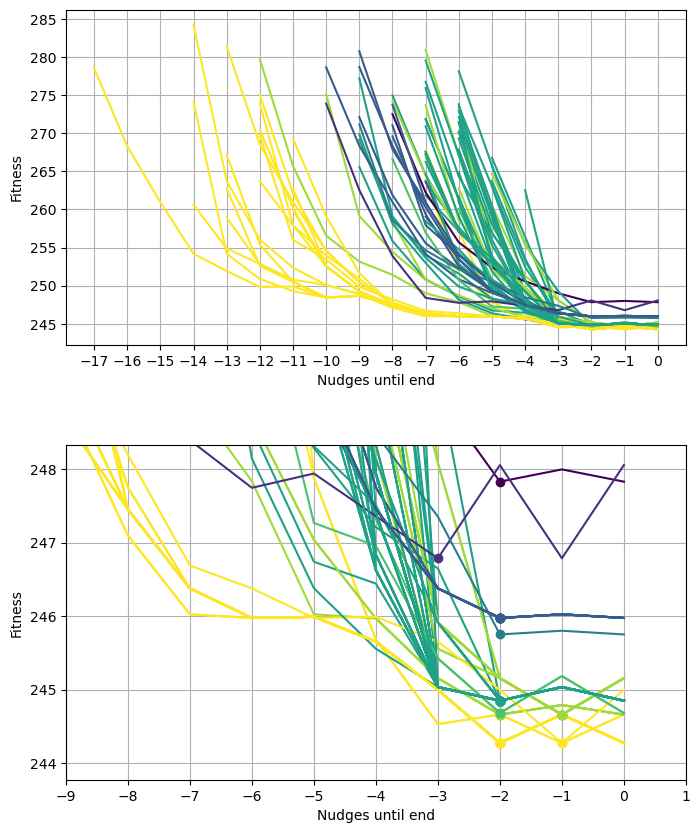

In [30]:
colours = plt.get_cmap('viridis')(np.linspace(1.0, 0.0, len(coeffs_unique)))
# Set up which unique label should get each colour:
unique_labels_by_fitness = df_unique_lookup['label'][np.argsort(df_unique_lookup['fitness'])].to_numpy().flatten()


# Two axes, one for the full data and one zoomed in on the results.
fig, axs = plt.subplots(
    2, 1, figsize=(8, 10),
    gridspec_kw={'height_ratios': [1.0, 1.0], 'hspace':0.3}
)

for d, df in dict_nudged_results.items():
    # Full data axis:
    x_vals = np.arange(-len(df)+1, 1.0, 1.0)
    # Select colour:
    u = df_best_nudged.filter(df_best_nudged['dir'] == d)['unique_label'].to_numpy().flatten()
    v = np.where(unique_labels_by_fitness == u)
    # Draw line:
    l, = axs[0].plot(x_vals, df['fitness'], color=colours[v])
    # Extract colour so other lines for the same data share colour:
    colour = l.get_color()
    # Repeat plot for zoomed-in axis:
    axs[1].plot(x_vals, df['fitness'], color=colour)
    # Mark the final fitness value:
    axs[1].scatter(
        1.0 - len(df) + np.where(df['fitness'] == df['fitness'].min())[0][0],
        df['fitness'].min(), color=colour, zorder=5
    )

for ax in axs:
    ax.set_ylabel('Fitness')
    ax.set_xlabel('Nudges until end')
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(1))
    ax.grid()
axs[1].set_ylim(
    df_check_history['fitness_after'].min()-0.5,
    df_check_history['fitness_after'].max()+0.5
)
axs[1].set_xlim(-9, 1)
plt.show()

Most coefficients have moved to a fitness of around 245. Assume that the best answer is somewhere around there. The coefficients have all reached that similar level regardless of whether their fitness before was around 250 or around 270.

## Full results

How many unique sets of coefficients are there?

In [26]:
coeffs_unique = np.unique(np.round(df_best_nudged[coeff_names], 4), axis=0)
dict_coeffs_unique = dict(zip(range(len(coeffs_unique)), coeffs_unique))
# coeffs_unique = np.unique(np.round(df_best_nudged.filter(df_best_nudged['fitness'] <= 245)[coeff_names], 4), axis=0)

print(len(coeffs_unique))

8


Label the 100 sets of coeffs as these unique values:

In [27]:
unique_labels = []

for i in range(len(df_best_nudged)):
    coeffs_here = np.round(df_best_nudged[coeff_names][i], 4)
    # Which set of coeffs does this match?
    mask = np.all(coeffs_here == list(dict_coeffs_unique.values()), axis=1)
    # Where is this set of coeffs in the list...
    ind = np.where(mask)[0][0]
    # ... and what is its name?
    u = list(dict_coeffs_unique.keys())[ind]
    unique_labels.append(u)

df_best_nudged = df_best_nudged.with_columns(pl.Series('unique_label', unique_labels))

View which sets of coeffs have each unique label:

In [28]:
dict_unique_lookup = {
    'label': [],
    'size': [],
    'fitness': [],
    'dirs': [],
}

for u, coeffs in dict_coeffs_unique.items():
    df_here = df_best_nudged.filter(df_best_nudged['unique_label'] == u)
    dirs_here = df_here.sort('dir')['dir']
    dict_unique_lookup['label'].append(u)
    dict_unique_lookup['size'].append(len(dirs_here))
    dict_unique_lookup['fitness'].append(df_here['fitness'][0])
    dict_unique_lookup['dirs'].append(dirs_here.to_numpy().flatten())

df_unique_lookup = pl.DataFrame()
for key, vals in dict_unique_lookup.items():
    df_unique_lookup = df_unique_lookup.with_columns(pl.Series(key, vals))

In [29]:
# Set config to display all elements of the dir lists:
with pl.Config(set_fmt_table_cell_list_len=df_unique_lookup['size'].max()):
    display(df_unique_lookup.sort('fitness'))

label,size,fitness,dirs
i64,i64,f64,list[str]
7,21,244.272812,"[""randomseed00"", ""randomseed08"", ""randomseed09"", ""randomseed12"", ""randomseed14"", ""randomseed21"", ""randomseed30"", ""randomseed36"", ""randomseed42"", ""randomseed49"", ""randomseed55"", ""randomseed58"", ""randomseed70"", ""randomseed72"", ""randomseed74"", ""randomseed76"", ""randomseed77"", ""randomseed86"", ""randomseed89"", ""randomseed93"", ""randomseed99""]"
5,14,244.659179,"[""randomseed04"", ""randomseed11"", ""randomseed17"", ""randomseed19"", ""randomseed32"", ""randomseed37"", ""randomseed39"", ""randomseed54"", ""randomseed56"", ""randomseed61"", ""randomseed63"", ""randomseed84"", ""randomseed91"", ""randomseed92""]"
4,2,244.681399,"[""randomseed03"", ""randomseed46""]"
3,51,244.849126,"[""randomseed01"", ""randomseed02"", ""randomseed07"", ""randomseed10"", ""randomseed13"", ""randomseed15"", ""randomseed16"", ""randomseed20"", ""randomseed22"", ""randomseed23"", ""randomseed24"", ""randomseed25"", ""randomseed26"", ""randomseed28"", ""randomseed29"", ""randomseed31"", ""randomseed33"", ""randomseed34"", ""randomseed35"", ""randomseed38"", ""randomseed40"", ""randomseed41"", ""randomseed43"", ""randomseed44"", ""randomseed51"", ""randomseed52"", ""randomseed53"", ""randomseed57"", ""randomseed59"", ""randomseed64"", ""randomseed65"", ""randomseed66"", ""randomseed67"", ""randomseed68"", ""randomseed69"", ""randomseed71"", ""randomseed73"", ""randomseed75"", ""randomseed78"", ""randomseed80"", ""randomseed82"", ""randomseed83"", ""randomseed85"", ""randomseed87"", ""randomseed88"", ""randomseed90"", ""randomseed94"", ""randomseed95"", ""randomseed96"", ""randomseed97"", ""randomseed98""]"
1,1,245.750756,"[""randomseed62""]"
6,9,245.975053,"[""randomseed05"", ""randomseed06"", ""randomseed18"", ""randomseed47"", ""randomseed48"", ""randomseed50"", ""randomseed60"", ""randomseed79"", ""randomseed81""]"
0,1,246.787816,"[""randomseed27""]"
2,1,247.830937,"[""randomseed45""]"


The set of coefficients with the best fitness is found by 21 of the 100 starting sets.

View the coefficients and their differences from the best set:

In [31]:
inds = np.arange(25).reshape(5, 5).transpose().flatten()

inds

array([ 0,  5, 10, 15, 20,  1,  6, 11, 16, 21,  2,  7, 12, 17, 22,  3,  8,
       13, 18, 23,  4,  9, 14, 19, 24])

In [32]:
coeff_names_by_age = np.array(coeff_names)[inds]


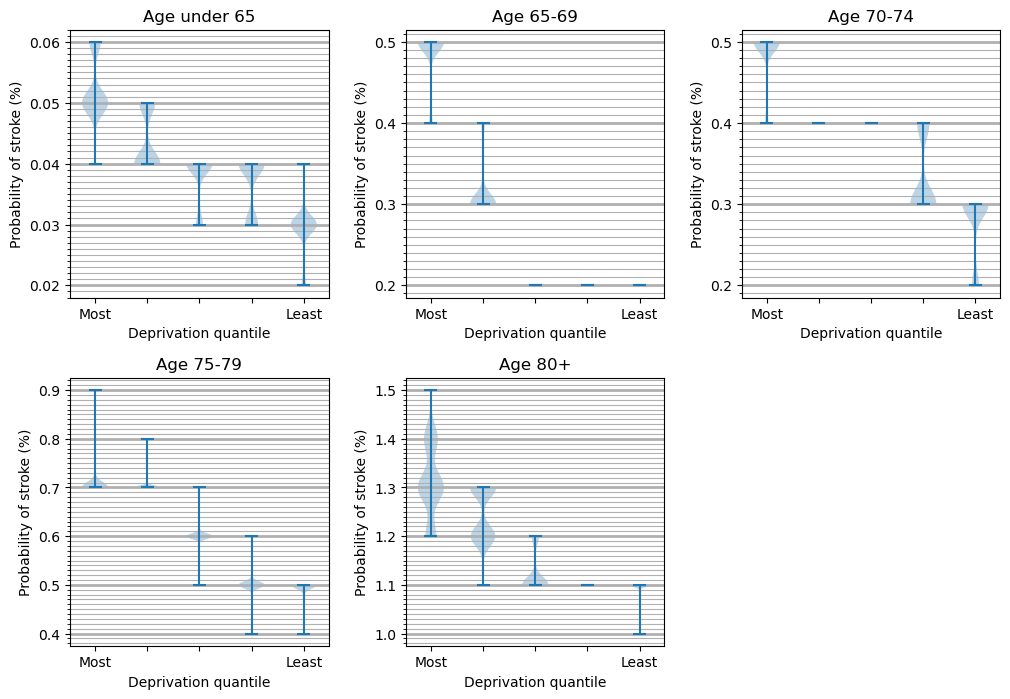

In [33]:
age_band_label_dict = {'age_less65': 'Age under 65', 'age_65': 'Age 65-69', 'age_70': 'Age 70-74', 'age_75': 'Age 75-79', 'age_over80': 'Age 80+'}
# qmin_label_dict = {'q00': '0-20%', 'q02': '20-40%', 'q04': '40-60%', 'q06': '60-80%', 'q08': '80-100%'}
qmin_label_dict = {'q00': 'Most', 'q02': '', 'q04': '', 'q06': '', 'q08': 'Least'}

fig, axs = plt.subplots(2, 3, figsize=(12, 8), gridspec_kw={'hspace': 0.3, 'wspace': 0.3})

for i in range(5):
    ax = axs[i // 3, i % 3]
    
    # for i, c in enumerate(coeff_names):
    #     ax.violinplot(df_best_gens[c], )
    coeff_names_here = coeff_names_by_age[i*5:i*5+5]
    ax.violinplot(100.0 * df_best_nudged[coeff_names_here], positions=np.arange(5))

    title = age_band_label_dict['_'.join(coeff_names_here[0].split('_')[:-1])]
    ax.set_title(title)
    xticklabels = [qmin_label_dict[c.split('_')[-1]] for c in coeff_names_here]
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(xticklabels)#, rotation=30, ha='right')
    # ax.ticklabel_format(axis='y', style=None, scilimits=[-1, 0])

    # Mark every significant figure:
    tick_space = 100.0 * 1e-4 if i == 0 else 100.0 * 1e-3
    ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(tick_space))
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(tick_space*0.1))
    ax.grid(axis='y', which='both')#, linewidth=None)
    ax.grid(axis='y', which='major', linewidth=2)

    ax.set_xlabel('Deprivation quantile')
    ax.set_ylabel('Probability of stroke (%)')

axs[-1, -1].set_visible(False)

# plt.savefig(os.path.join('images', 'violin_coeffs_deap_output.png'), bbox_inches='tight', dpi=200)
plt.show()

In [34]:
for c in coeff_names:
    print(c)
    display(pl.Series(c, np.round(df_best_nudged[c], 6)).value_counts().sort(c))
    print('')

age_less65_q00


age_less65_q00,count
f64,u32
0.0004,1
0.0005,69
0.0006,30



age_65_q00


age_65_q00,count
f64,u32
0.004,11
0.005,89



age_70_q00


...

age_70_q08,count
f64,u32
0.002,21
0.003,79



age_75_q08


age_75_q08,count
f64,u32
0.004,4
0.005,96



age_over80_q08


age_over80_q08,count
f64,u32
0.01,1
0.011,99


In [35]:
best_nudged_coeffs = df_best_nudged.sort('fitness')[0][coeff_names].to_numpy().flatten()

In [36]:
# for u, coeffs in dict_coeffs_unique.items():
for u, key in enumerate(df_best_nudged.sort('fitness')['dir'].to_numpy()):
    df = df_best_nudged.filter(df_best_nudged['dir'] == key)[0]
    coeffs = df[coeff_names].to_numpy()
    fitness = df['fitness'].to_numpy()[0]
    # fitness = df_unique_lookup.filter(df_unique_lookup['label'] == u)['fitness'][0]
    print(f'Set {u}, fitness {fitness:.2f}')
    print('Coeffs:')
    print(coeffs.reshape(5, 5))
    print('Change from best coeffs:')
    print(coeffs.reshape(5, 5) - best_nudged_coeffs.reshape(5, 5))
    print('')

Set 0, fitness 244.27
Coeffs:
[[0.0006 0.005  0.005  0.007  0.012 ]
 [0.0005 0.003  0.004  0.007  0.012 ]
 [0.0003 0.002  0.004  0.006  0.012 ]
 [0.0003 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.002  0.005  0.011 ]]
Change from best coeffs:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Set 1, fitness 244.27
Coeffs:
[[0.0006 0.005  0.005  0.007  0.012 ]
 [0.0005 0.003  0.004  0.007  0.012 ]
 [0.0003 0.002  0.004  0.006  0.012 ]
 [0.0003 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.002  0.005  0.011 ]]
Change from best coeffs:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

Set 2, fitness 244.27
Coeffs:
[[0.0006 0.005  0.005  0.007  0.012 ]
 [0.0005 0.003  0.004  0.007  0.012 ]
 [0.0003 0.002  0.004  0.006  0.012 ]
 [0.0003 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.002  0.005  0.011 ]]
Change from best coeffs:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0

The alternative sets of coeffs have typically 8 or 9 elements changed from the best set.

### Check each age band separately

Split the coefficients into their age bands. Then don't compare the full set of 25, but just the 5 coefficients in an age band. There are far fewer options when there are only five coefficients.

How many sets of coefficients fall into each option?

In [37]:
age_bands = ['less65', '65', '70', '75', 'over80']
for age in age_bands:
    cols_here = [c for c in df_best_nudged.columns if f'_{age}_' in c]
    options = np.unique(np.round(df_best_nudged[cols_here], 4), axis=0)
    
    print(f'Age band: {age}')
    for coeff_list in options:
        mask = np.all(np.round(df_best_nudged[cols_here].to_numpy(), 4) == np.round(coeff_list, 4), axis=1)
        dirs = df_best_nudged.filter(mask)['dir'].to_numpy()
        print(coeff_list, len(dirs))#, dirs)
    print('\n')

Age band: less65
[0.0004 0.0004 0.0004 0.0004 0.0004] 1
[0.0005 0.0004 0.0004 0.0004 0.0003] 52
[0.0005 0.0005 0.0004 0.0003 0.0003] 3
[0.0005 0.0005 0.0004 0.0004 0.0002] 14
[0.0006 0.0004 0.0004 0.0003 0.0003] 9
[0.0006 0.0005 0.0003 0.0003 0.0003] 21


Age band: 65
[0.004 0.004 0.002 0.002 0.002] 11
[0.005 0.003 0.002 0.002 0.002] 89


Age band: 70
[0.004 0.004 0.004 0.004 0.003] 11
[0.005 0.004 0.004 0.003 0.003] 68
[0.005 0.004 0.004 0.004 0.002] 21


Age band: 75
[0.007 0.007 0.006 0.005 0.005] 96
[0.007 0.007 0.006 0.006 0.004] 2
[0.009 0.007 0.007 0.004 0.004] 1
[0.009 0.008 0.005 0.005 0.004] 1


Age band: over80
[0.012 0.012 0.012 0.011 0.011] 21
[0.013 0.013 0.011 0.011 0.011] 51
[0.014 0.012 0.011 0.011 0.011] 26
[0.014 0.012 0.012 0.011 0.01 ] 1
[0.015 0.011 0.011 0.011 0.011] 1




These is most variation in values in the under-65 age band (4 options are picked by more than 3 sets of coeffs). There is least variation in the 75-80 age band (96/100 sets pick one option). 

## Path to best coefficients

View the starting sets of coefficients that resulted in the best set. View the nudges that happened to move them to the best set.

In [38]:
# Pick out the names of sets that meet the best fitness:
best_nudged_fitness = df_best_nudged['fitness'].min()
mask = np.round(df_best_nudged['fitness'], 5) == np.round(best_nudged_fitness, 5)
best_dirs = df_best_nudged.filter(mask).sort('fitness')['dir'].to_numpy().flatten()

Print best set for reference:

In [39]:
print(best_nudged_coeffs.reshape(5, 5))

[[0.0006 0.005  0.005  0.007  0.012 ]
 [0.0005 0.003  0.004  0.007  0.012 ]
 [0.0003 0.002  0.004  0.006  0.012 ]
 [0.0003 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.002  0.005  0.011 ]]


In [40]:
for d in best_dirs:
    print(d)
    start_coeffs = df_best_gens.filter(df_best_gens['dir'] == d)[coeff_names].to_numpy().flatten()
    print(start_coeffs.reshape(5, 5))
    print('Nudges to reach best values:')
    print(best_nudged_coeffs.reshape(5, 5) - start_coeffs.reshape(5, 5))
    print('')

randomseed09
[[0.0005 0.003  0.004  0.007  0.014 ]
 [0.0005 0.003  0.004  0.006  0.013 ]
 [0.0004 0.003  0.004  0.006  0.012 ]
 [0.0004 0.003  0.004  0.005  0.011 ]
 [0.0004 0.002  0.003  0.005  0.01  ]]
Nudges to reach best values:
[[ 0.0001  0.002   0.001   0.     -0.002 ]
 [ 0.      0.      0.      0.001  -0.001 ]
 [-0.0001 -0.001   0.      0.      0.    ]
 [-0.0001 -0.001   0.      0.      0.    ]
 [-0.0001  0.     -0.001   0.      0.001 ]]

randomseed12
[[0.0005 0.004  0.004  0.007  0.015 ]
 [0.0004 0.003  0.004  0.007  0.013 ]
 [0.0004 0.003  0.004  0.006  0.012 ]
 [0.0004 0.003  0.004  0.005  0.01  ]
 [0.0004 0.002  0.003  0.005  0.01  ]]
Nudges to reach best values:
[[ 0.0001  0.001   0.001   0.     -0.003 ]
 [ 0.0001  0.      0.      0.     -0.001 ]
 [-0.0001 -0.001   0.      0.      0.    ]
 [-0.0001 -0.001   0.      0.      0.001 ]
 [-0.0001  0.     -0.001   0.      0.001 ]]

randomseed49
[[0.0005 0.003  0.004  0.008  0.014 ]
 [0.0004 0.003  0.004  0.006  0.014 ]
 [0.0004 0.

How many iterations of nudges were there for these sets?

In [41]:
df_check_history_best = df_check_history.filter(df_check_history['dir'].is_in(best_dirs))

# Add a column to estimate how many options were checked.
# Subtract one because these dataframes store a copy of the starting values.
df_check_history_best = df_check_history_best.with_columns(pl.Series('n_options', (df_check_history_best['n_loops'] - 1) * 900))

with pl.Config(set_tbl_rows=len(best_dirs)):
    display(df_check_history_best)

dir,n_loops,fitness_before,fitness_after,n_nudges,n_options
str,i64,f64,f64,i64,i64
"""randomseed49""",15,260.632866,244.272812,9,12600
"""randomseed30""",8,267.810327,244.272812,6,6300
"""randomseed77""",8,263.928968,244.272812,6,6300
"""randomseed74""",11,252.546109,244.272812,6,9000
"""randomseed93""",12,269.307493,244.272812,6,9900
"""randomseed12""",15,274.092701,244.272812,8,12600
"""randomseed76""",13,270.415414,244.272812,6,10800
"""randomseed21""",12,262.735211,244.272812,6,9900
"""randomseed00""",13,273.891734,244.272812,7,10800


In [42]:
df_check_history_best.mean()

dir,n_loops,fitness_before,fitness_after,n_nudges,n_options
str,f64,f64,f64,f64,f64
null,12.904762,267.4786,244.272812,6.571429,10714.285714


Typically the best option was found after 13 iterations for around 10,700 options checked and 6 or 7 coefficients nudged.

## Compare best coeffs with SSNAP-derived coefficients

Compare the final coefficients with the starting point.

In [43]:
coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

These values rounded:

In [44]:
coeffs_ssnap_round = [0.0004, 0.003, 0.004, 0.006, 0.012]
# coeffs_ssnap_round = [0.00041, 0.0026, 0.0037, 0.0060, 0.012]

In [45]:
best_nudged_coeffs.reshape(5, 5)

array([[0.0006, 0.005 , 0.005 , 0.007 , 0.012 ],
       [0.0005, 0.003 , 0.004 , 0.007 , 0.012 ],
       [0.0003, 0.002 , 0.004 , 0.006 , 0.012 ],
       [0.0003, 0.002 , 0.004 , 0.005 , 0.011 ],
       [0.0003, 0.002 , 0.002 , 0.005 , 0.011 ]])

No row of coefficients matches the original coefficients exactly. The closest matches are the rows for the second-most and third-most deprived areas (second and third row). 

Each column contains a mix of values that are larger and smaller than the original value. The overall admissions for the SSNAP-derived coefficients were quite close to the observed total admissions, so it makes sense that the values haven't strayed too far from the starting point.

## Conclusion

Most sets of coefficients end up nudged to a set with fitness of around 245 regardless of the starting fitness value. This suggests that there are no substantially better answers that we've missed.

Use the set of coefficients with the best fitness as the definitive final values.